<a href="https://colab.research.google.com/github/zastrozhnayayana/nn-zero-to-hero-notes/blob/main/01_micrograd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import math

In [6]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [7]:
class Value:
  def __init__(self, x, children=[], op='', label=""):
    self.data = x
    self.grad = 0
    self.backward = lambda: None
    self._prev = children
    self.label = label
    self._op = op

  def __mul__(self, other):
    out = Value(self.data * other.data, [self, other], '*')
    def backward():
      self.grad += other.data * out.grad # self.grad это сумма по всем d[self.data]/d[out.data] * out.grad для каждого out, полученного из self
      other.grad += self.data * out.grad # + chain rule
    out.backward = backward # сохранили ф-ию в аттрибут класса, также в ф-ии сохранились ссылки на переменные, которые находятся во внешней области, но используются внутри неё
    return out

  def __add__(self, other):
    out = Value(self.data + other.data, [self, other], '+')
    def backward():
      self.grad += out.grad
      other.grad += out.grad
    out.backward = backward
    return out

  def tanh(self):
    out = Value(math.tanh(self.data), [self], 'tanh')
    def backward():
      self.grad += (1 - out.data ** 2) * out.grad
    out.backward = backward
    return out

  def go_backward(self):
    used = set()

    def dfs(v):
      v.backward()
      used.add(v)
      for u in v._prev:
        if u in used:
          continue
        dfs(u)

    dfs(self)

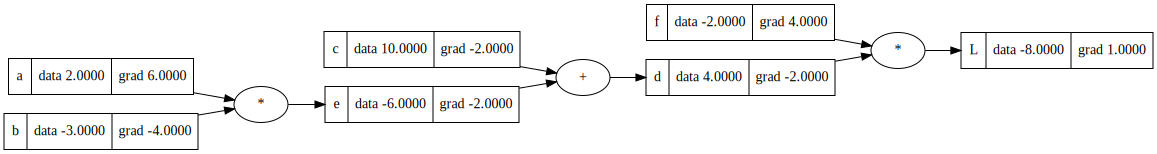

In [8]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L.grad = 1
L.go_backward()
draw_dot(L)